In [2]:
from DataCleaning import load_data,get_info,get_shape,get_head,get_summary_statistics,check_data_types,check_missing_values,check_duplicates,check_outliers,check_inconsistent_data,clean_data
from FeatureEngineering import feature_engineering,customer_features,rfm
from visualizations import merge_rfm,plot_seasonality,plot_rfm_segment_distribution,plot_dominant_segment_heatmap,plot_discount_vs_profit_margin,plot_revenue_by_region,plot_revenue_trend,plot_top_products_revenue_vs_profit,plot_aov_by_segment

import matplotlib.pyplot as plt


## 1. Load Data

In [3]:
path="Sample - Superstore 2019.csv"
df=load_data(path)

## 2. Inspect Data

In [4]:
get_info(df)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 9996 entries, 0 to 9995
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          9994 non-null   float64       
 1   Order ID        9994 non-null   str           
 2   Order Date      9994 non-null   datetime64[us]
 3   Ship Date       9994 non-null   datetime64[us]
 4   Ship Mode       9994 non-null   str           
 5   Customer ID     9994 non-null   str           
 6   Customer Name   9994 non-null   str           
 7   Segment         9994 non-null   str           
 8   Country/Region  9994 non-null   str           
 9   City            9994 non-null   str           
 10  State           9994 non-null   str           
 11  Postal Code     9983 non-null   float64       
 12  Region          9994 non-null   str           
 13  Product ID      9994 non-null   str           
 14  Category        9994 non-null   str           

In [5]:
get_head(df)

   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0     1.0  CA-2018-152156 2018-11-08 2018-11-11    Second Class    CG-12520   
1     2.0  CA-2018-152156 2018-11-08 2018-11-11    Second Class    CG-12520   
2     3.0  CA-2018-138688 2018-06-12 2018-06-16    Second Class    DV-13045   
3     4.0  US-2017-108966 2017-10-11 2017-10-18  Standard Class    SO-20335   
4     5.0  US-2017-108966 2017-10-11 2017-10-18  Standard Class    SO-20335   

     Customer Name    Segment Country/Region             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0     42420.0   South  FUR-BO-10

In [6]:
get_shape(df)

Dataset Shape:
(9996, 21)


In [7]:
get_summary_statistics(df)

Summary Statistics:
             Row ID        Order ID                  Order Date  \
count   9994.000000            9994                        9994   
unique          NaN            5009                         NaN   
top             NaN  CA-2019-100111                         NaN   
freq            NaN              14                         NaN   
mean    4997.500000             NaN  2018-04-30 10:03:51.979187   
min        1.000000             NaN         2016-01-03 00:00:00   
25%     2499.250000             NaN         2017-05-23 00:00:00   
50%     4997.500000             NaN         2018-06-26 00:00:00   
75%     7495.750000             NaN         2019-05-14 00:00:00   
max     9994.000000             NaN         2019-12-30 00:00:00   
std     2885.163629             NaN                         NaN   

                         Ship Date       Ship Mode Customer ID  Customer Name  \
count                         9994            9994        9994           9994   
unique       

In [8]:
check_data_types(df)

Data Types:
Row ID                   float64
Order ID                     str
Order Date        datetime64[us]
Ship Date         datetime64[us]
Ship Mode                    str
Customer ID                  str
Customer Name                str
Segment                      str
Country/Region               str
City                         str
State                        str
Postal Code              float64
Region                       str
Product ID                   str
Category                     str
Sub-Category                 str
Product Name                 str
Sales                    float64
Quantity                 float64
Discount                 float64
Profit                   float64
dtype: object


In [9]:
check_missing_values(df)

Missing Values:
Row ID             2
Order ID           2
Order Date         2
Ship Date          2
Ship Mode          2
Customer ID        2
Customer Name      2
Segment            2
Country/Region     2
City               2
State              2
Postal Code       13
Region             2
Product ID         2
Category           2
Sub-Category       2
Product Name       2
Sales              2
Quantity           2
Discount           2
Profit             2
dtype: int64


In [10]:
check_duplicates(df)

Duplicate records found: 1


In [11]:
check_outliers(df, 'Sales')

Outliers in Sales:
          Sales
1      731.9400
3      957.5775
7      907.1520
10    1706.1840
11     911.4240
...         ...
9931   683.3320
9942   998.8200
9947  1925.8800
9948  2405.2000
9968   735.9800

[1167 rows x 1 columns]


In [12]:
check_inconsistent_data(
    df,
    ['Ship Mode', 'Segment', 'Country/Region', 'City', 'State', 'Region', 'Category', 'Sub-Category']
)

Inconsistent values in Ship Mode:
<StringArray>
['Second Class', 'Standard Class', 'First Class', 'Same Day', nan]
Length: 5, dtype: str
Inconsistent values in Segment:
<StringArray>
['Consumer', 'Corporate', 'Home Office', nan]
Length: 4, dtype: str
Inconsistent values in Country/Region:
<StringArray>
['United States', nan]
Length: 2, dtype: str
Inconsistent values in City:
<StringArray>
[        'Henderson',       'Los Angeles',   'Fort Lauderdale',
           'Concord',           'Seattle',        'Fort Worth',
           'Madison',       'West Jordan',     'San Francisco',
           'Fremont',
 ...
       'East Orange', 'Arlington Heights',            'Oswego',
       'Coon Rapids',      'San Clemente',   'San Luis Obispo',
        'Springdale',              'Lodi',             'Mason',
                 nan]
Length: 532, dtype: str
Inconsistent values in State:
<StringArray>
[            'Kentucky',           'California',              'Florida',
       'North Carolina',          

In [13]:
df = clean_data(df)

Duplicate records found: 0


## 4. Feature Engineering

In [14]:

df=feature_engineering(df)

In [15]:
CustomerFeatures=customer_features(df)

In [16]:
CustomerFeatures

,Customer ID,order_count,total_spend,total_profit,avg_order_value,first_order,last_order,Customer Tenure Days
0,AA-10315,5,959.920,170.5439,106.657778,2016-03-31,2019-06-29,1185
1,AA-10375,9,556.410,162.3870,39.743571,2016-04-21,2019-12-11,1329
2,AA-10480,4,1790.512,435.8274,149.209333,2016-05-04,2019-04-15,1076
3,AA-10645,6,1088.700,242.7249,77.764286,2016-06-22,2019-11-05,1231
4,AB-10015,3,886.156,129.3465,147.692667,2016-02-18,2018-11-10,996
...,...,...,...,...,...,...,...,...
785,XP-21865,11,2374.658,621.2300,84.809214,2016-01-20,2019-11-17,1397
786,YC-21895,3,569.364,100.8334,113.872800,2016-11-17,2018-09-06,658
787,YS-21880,7,1926.876,255.4650,214.097333,2017-01-12,2019-08-18,948
788,ZC-21910,13,2047.373,125.4253,78.745115,2016-10-13,2019-11-06,1119


In [17]:
rfm=rfm(df)

In [18]:
rfm

,Customer ID,recency,frequency,monetary_value,r_score,f_score,m_score,RFM_Score,Customer Segment
784,WB-21850,21,11,3131.974,5,5,5,555,Champion
753,TP-21130,9,8,1582.566,5,5,5,555,Champion
621,RB-19465,10,11,2276.064,5,5,5,555,Champion
616,RA-19915,13,9,1896.145,5,5,5,555,Champion
699,SM-20950,26,11,1940.360,5,5,5,555,Champion
...,...,...,...,...,...,...,...,...,...
725,SW-20755,535,2,179.560,1,1,1,111,Lost
145,CJ-11875,366,1,16.520,1,1,1,111,Lost
144,CH-12070,792,2,409.260,1,1,1,111,Lost
143,CG-12520,339,3,416.840,1,1,1,111,Lost


In [19]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country/Region',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit',
 'Month',
 'Year',
 'Day',
 'Quarter',
 'Shipping Duration',
 'Is Weekend',
 'Unit Price',
 'Profit Margin']

In [20]:
get_head(df)

   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2018-152156 2018-11-08 2018-11-11    Second Class    CG-12520   
2       3  CA-2018-138688 2018-06-12 2018-06-16    Second Class    DV-13045   
4       5  US-2017-108966 2017-10-11 2017-10-18  Standard Class    SO-20335   
5       6  CA-2016-115812 2016-06-09 2016-06-14  Standard Class    BH-11710   
6       7  CA-2016-115812 2016-06-09 2016-06-14  Standard Class    BH-11710   

     Customer Name    Segment Country/Region             City  ... Discount  \
0      Claire Gute   Consumer  United States        Henderson  ...      0.0   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...      0.0   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...      0.2   
5  Brosina Hoffman   Consumer  United States      Los Angeles  ...      0.0   
6  Brosina Hoffman   Consumer  United States      Los Angeles  ...      0.0   

    Profit Month  Year        Day Quarter Shipping

In [21]:
df=merge_rfm(df, rfm)

In [22]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country/Region',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit',
 'Month',
 'Year',
 'Day',
 'Quarter',
 'Shipping Duration',
 'Is Weekend',
 'Unit Price',
 'Profit Margin',
 'Customer Segment']

## 5. Questions and Viz


##### A.What's the distribution of customers across RFM Segments?


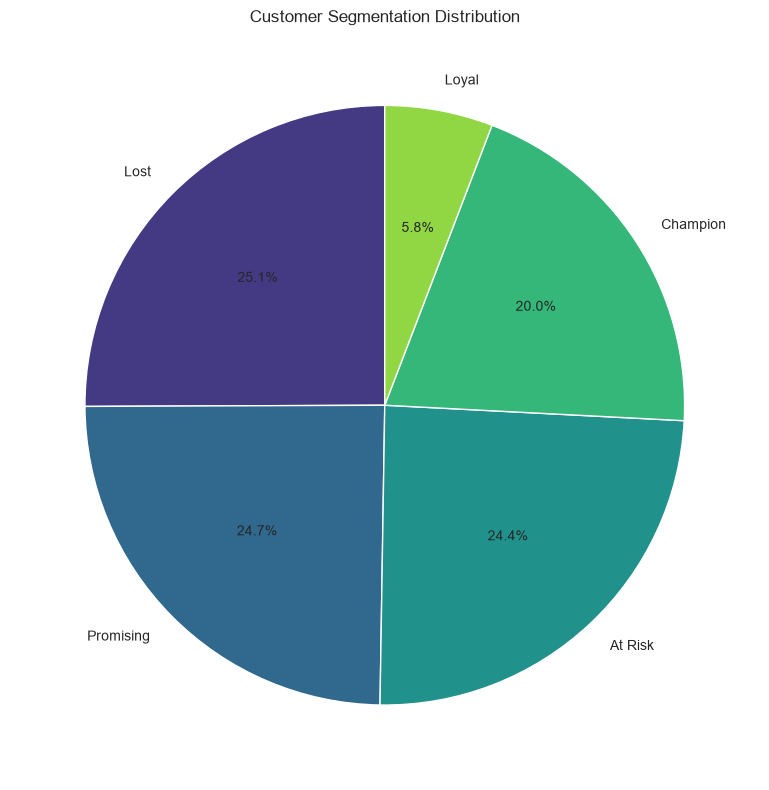

In [23]:
plot_rfm_segment_distribution(rfm)

##### B.What is the dominant (most frequent) RFM segment in each city/state?



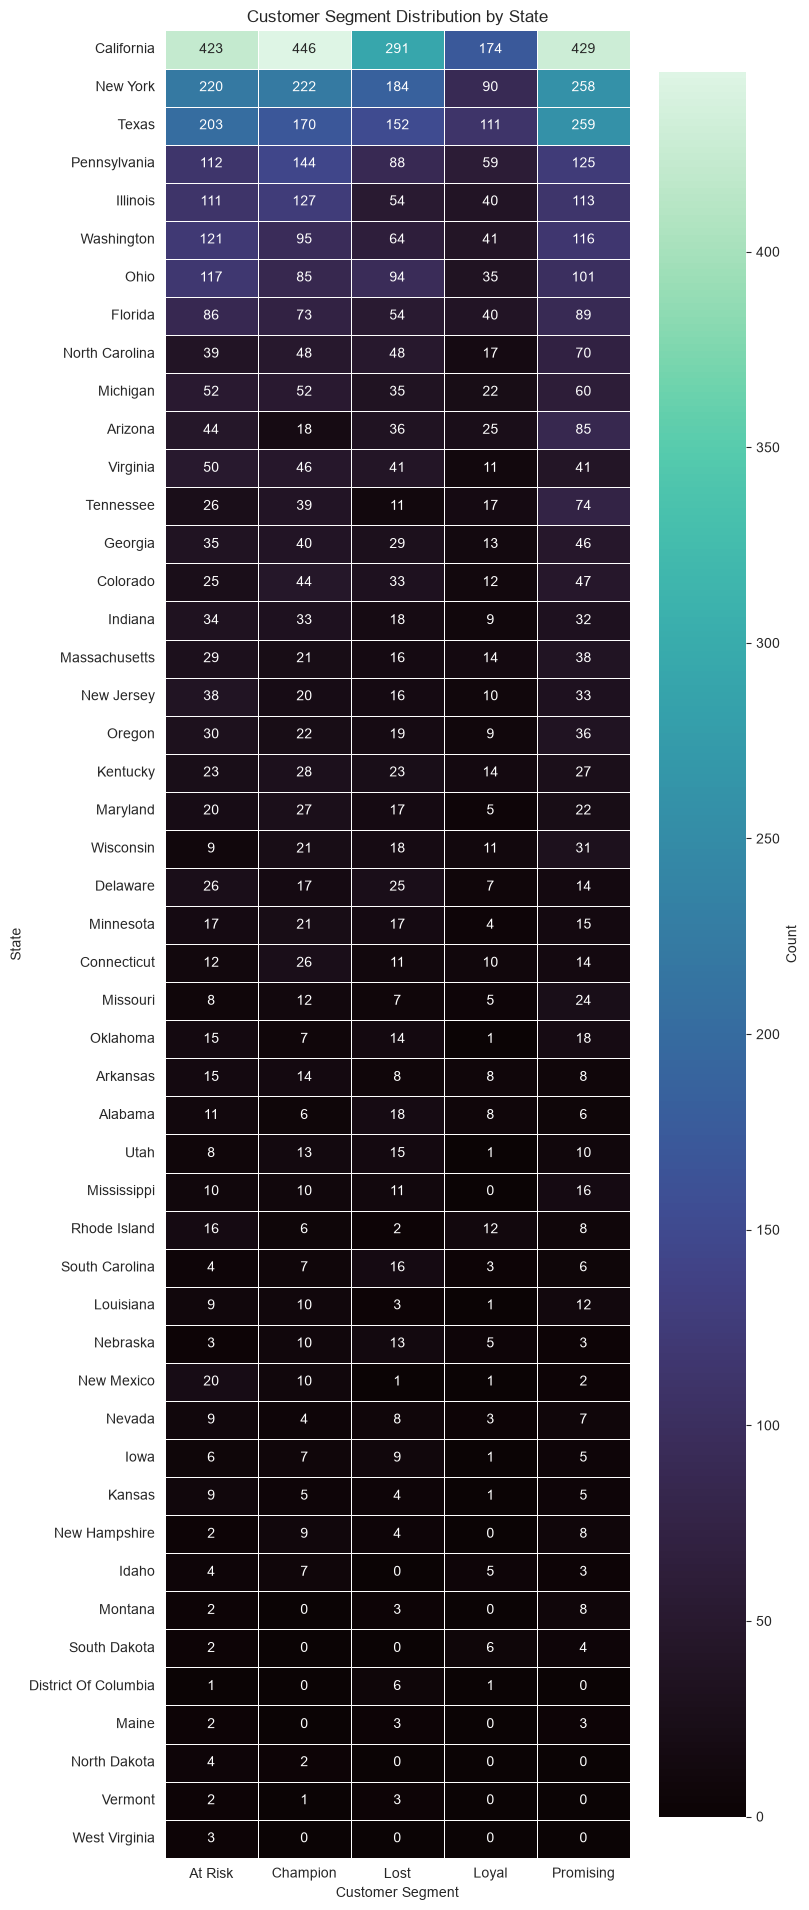

In [24]:
dominant_df = plot_dominant_segment_heatmap(df, region_col='State')

##### C.Which city/state generates the highest revenue/profit overall?



d:\Data Analysis\Mini Project 1\visualizations.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=revenue.values, y=revenue.index, palette='rocket')


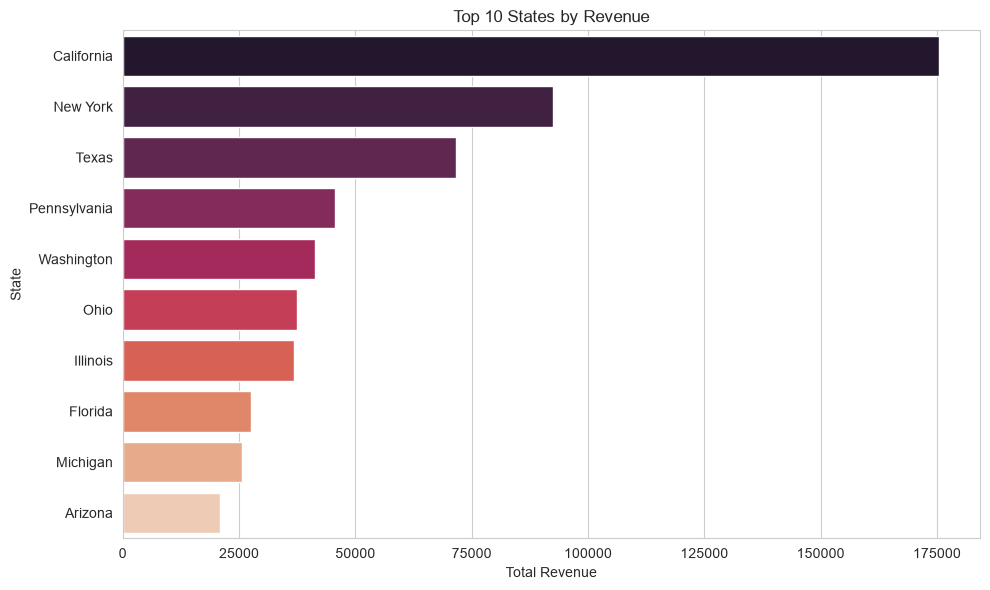

In [25]:
plot_revenue_by_region(df, region_col='State', top_n=10)

##### D.How does revenue/sales trend over time (monthly/yearly)?



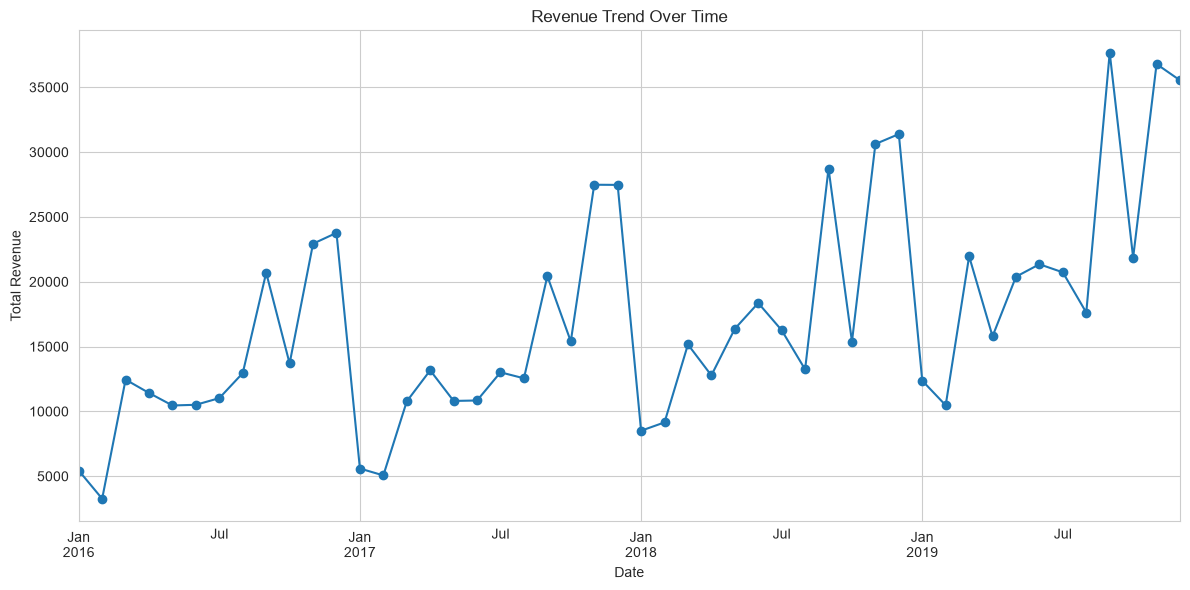

In [26]:
plot_revenue_trend(df)

##### E.What are the top products or categories by profit/revenue?



d:\Data Analysis\Mini Project 1\visualizations.py:109: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_revenue.values, y=top_revenue.index, palette='crest', ax=axes[0])
d:\Data Analysis\Mini Project 1\visualizations.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_profit.values, y=top_profit.index, palette='flare', ax=axes[1])


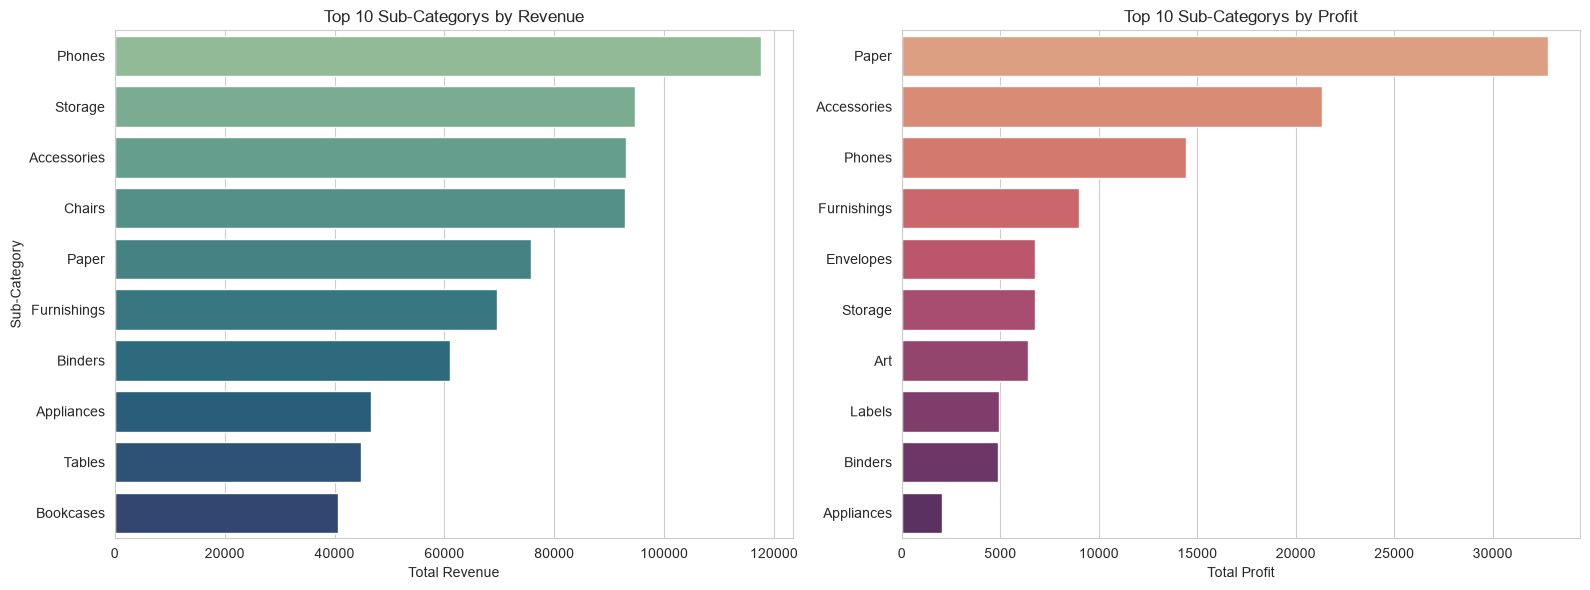

,Sales,Profit
Sub-Category,,
Phones,117585.5380,14416.5916
Storage,94705.9560,6735.5406
Accessories,93024.6840,21316.8009
Chairs,92925.4670,1626.0581
Paper,75857.9560,32795.3693
Furnishings,69562.1520,8988.7917
Binders,61012.2150,4901.3211
Appliances,46729.7030,2028.9706
Tables,44837.0475,-8636.2699


In [27]:
plot_top_products_revenue_vs_profit(df, product_col='Sub-Category', top_n=10)

##### F.What's the Average Order Value (AOV) for each RFM Segment?



d:\Data Analysis\Mini Project 1\visualizations.py:136: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=aov.values, y=aov.index, palette='flare')


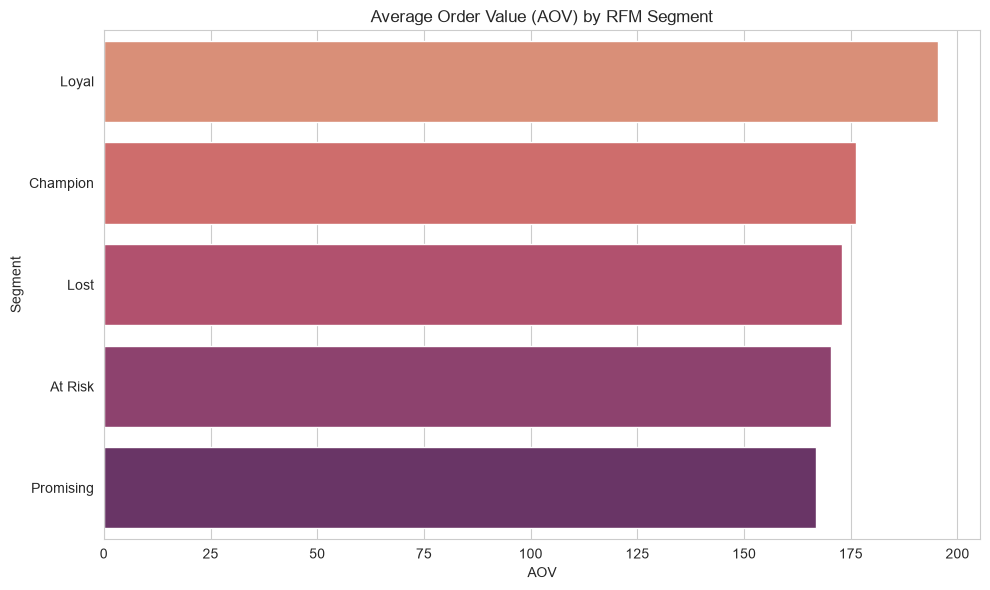

In [28]:
plot_aov_by_segment(df)

##### G.Does discount level affect profit margin?



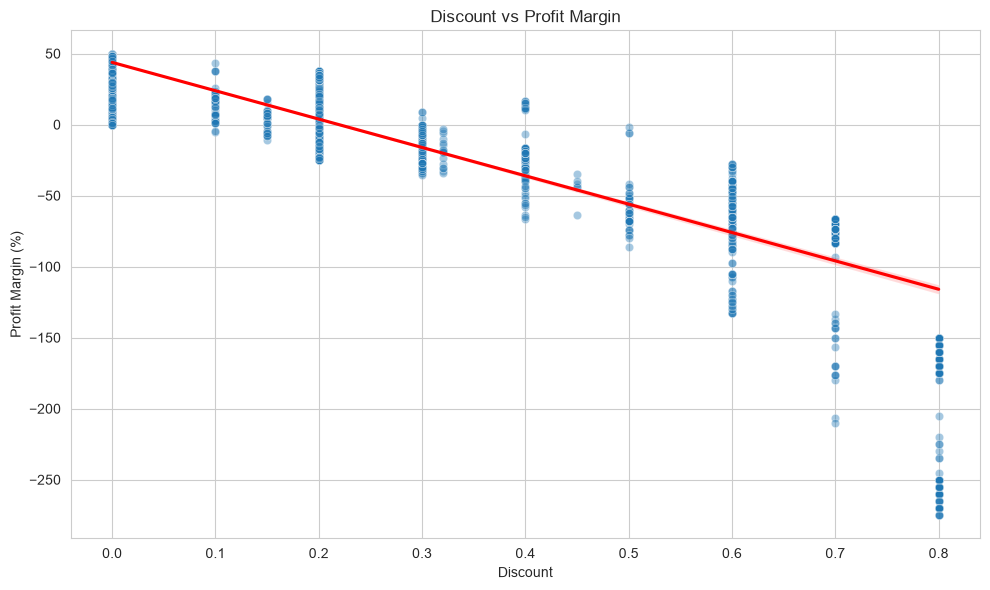

Correlation: -0.870


In [29]:
plot_discount_vs_profit_margin(df)

##### G. Is there seasonality in sales across months/quarters?

d:\Data Analysis\Mini Project 1\visualizations.py:165: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=seasonal.index, y=seasonal.values, palette='mako')


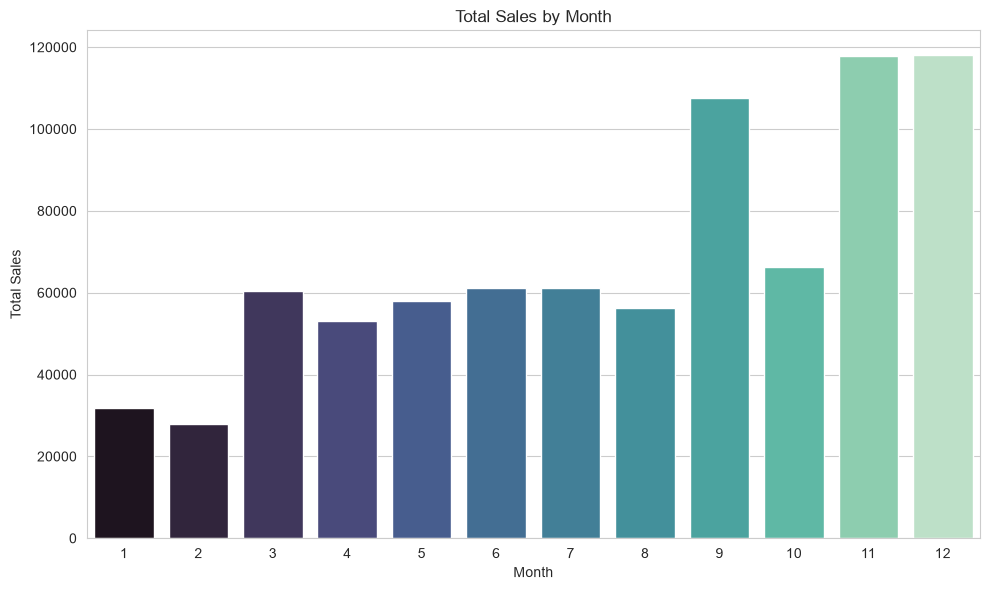

In [30]:
plot_seasonality(df)